In [1]:
import gzip
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In case of directory error

In [2]:
import os
print(os.getcwd())

c:\Users\aiden\OneDrive\Desktop\DS3-LocalLens


In [3]:
'''
def load_json_gzp(path: str) -> pd.DataFrame:
    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

STATE_NAME = "New_York"
meta_path = f"data/meta-{STATE_NAME}.json.gz" 
review_path = f"data/review-{STATE_NAME}.json.gz" 

df_meta = load_json_gzp(meta_path)
df_review = load_json_gzp(review_path)
'''

'\ndef load_json_gzp(path: str) -> pd.DataFrame:\n    records = []\n    with gzip.open(path, "rt", encoding="utf-8") as f:\n        for line in f:\n            records.append(json.loads(line))\n    return pd.DataFrame(records)\n\nSTATE_NAME = "New_York"\nmeta_path = f"data/meta-{STATE_NAME}.json.gz" \nreview_path = f"data/review-{STATE_NAME}.json.gz" \n\ndf_meta = load_json_gzp(meta_path)\ndf_review = load_json_gzp(review_path)\n'

In [4]:
# Memory-efficient data loader: processes large JSON files in chunks to prevent RAM overflow
def load_efficiently(path, columns_to_keep):
    """Loads JSON in chunks and keeps only specific columns to save RAM."""
    chunks = []
    # Read in chunks of 100,000 lines at a time
    reader = pd.read_json(path, lines=True, compression='gzip', chunksize=100000)
    
    for chunk in reader:
        # Keep only the columns necessary for your volatility analysis
        # This prevents RAM from ballooning
        chunks.append(chunk[columns_to_keep])
        
    return pd.concat(chunks, ignore_index=True)

STATE_NAME = "Vermont"
meta_path = f"data/meta-{STATE_NAME}.json.gz"
review_path = f"data/review-{STATE_NAME}.json.gz"

# Define only the columns your analysis actually uses
meta_cols = ['gmap_id', 'name', 'category', 'avg_rating', 'num_of_reviews']
review_cols = ['user_id', 'gmap_id', 'rating', 'time']

df_meta = load_efficiently(meta_path, meta_cols)
df_review = load_efficiently(review_path, review_cols)

Keep only business id, avg rating, and total # of reviews. Drop rows with missing values

In [5]:
biz = df_meta[["gmap_id", "avg_rating", "num_of_reviews"]].dropna()

biz["num_of_reviews"] = biz["num_of_reviews"].astype(int)
biz["avg_rating"] = biz["avg_rating"].astype(float)


In [6]:
# Binning: Grouping businesses by review volume to analyze statistical variance
bins = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, biz["num_of_reviews"].max() + 1]
labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]

biz["review_bin"] = pd.cut(biz["num_of_reviews"], bins=bins, labels=labels, right=False)

#Calculate statistics for each bin
stability_table = (biz.groupby("review_bin").agg(
        n_businesses=("gmap_id", "count"),
        rating_std=("avg_rating", "std"),
        rating_var=("avg_rating", "var"),
        mean_rating=("avg_rating", "mean"),
    ).reset_index())


print(stability_table)

  review_bin  n_businesses  rating_std  rating_var  mean_rating
0        1–1           597    1.077194    1.160346     4.397487
1        2–4          1407    0.791099    0.625837     4.391045
2        5–9          2240    0.641285    0.411247     4.385848
3      10–19          1623    0.535512    0.286773     4.419285
4      20–49          1966    0.483702    0.233967     4.407630
5      50–99          1387    0.434095    0.188438     4.424081
6    100–199           997    0.403046    0.162446     4.367803
7    200–499           809    0.382720    0.146474     4.316440
8    500–999           199    0.393118    0.154541     4.302010
9  1000–5498            66    0.357614    0.127888     4.363636


C:\Users\aiden\AppData\Local\Temp\ipykernel_39156\3179817672.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stability_table = (biz.groupby("review_bin").agg(


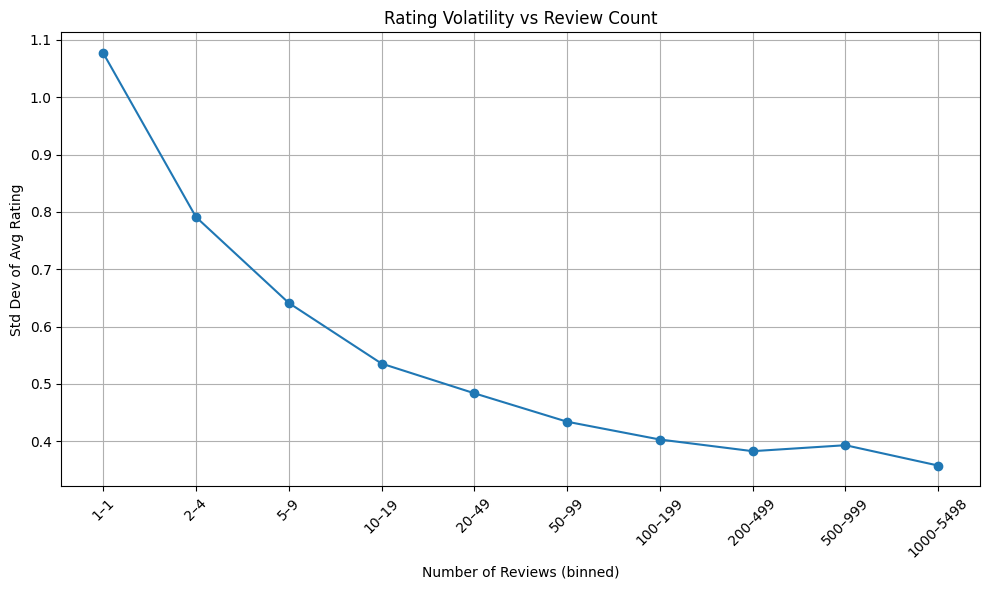

In [7]:
# Visualization: Plotting rating trends to identify stability thresholds
plt.figure(figsize=(10, 6))
plt.plot(stability_table["review_bin"], stability_table["rating_std"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Std Dev of Avg Rating")
plt.xlabel("Number of Reviews (binned)")
plt.title("Rating Volatility vs Review Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Binning: Grouping businesses by review volume to analyze statistical variance
biz = df_meta[["gmap_id", "avg_rating", "num_of_reviews", "category"]].dropna()

# Each row now has one category because some of the businesses had more than one category
biz_exploded = biz.explode('category')

# Find top 10 (so graph isn't cluttered)
top_cats = biz_exploded['category'].value_counts().head(10).index.tolist()

# Only top 10
df_filtered = biz_exploded[biz_exploded['category'].isin(top_cats)].copy()

bins = [0, 5, 10, 20, 50, 100, 250, 500, 1000, 5000]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-250', '251-500', '501-1k', '1k+']
df_filtered['review_bin'] = pd.cut(df_filtered['num_of_reviews'], bins=bins, labels=labels)

# Get variance of avg rating
stability_data = df_filtered.groupby(['category', 'review_bin'], observed=True)['avg_rating'].var().reset_index()

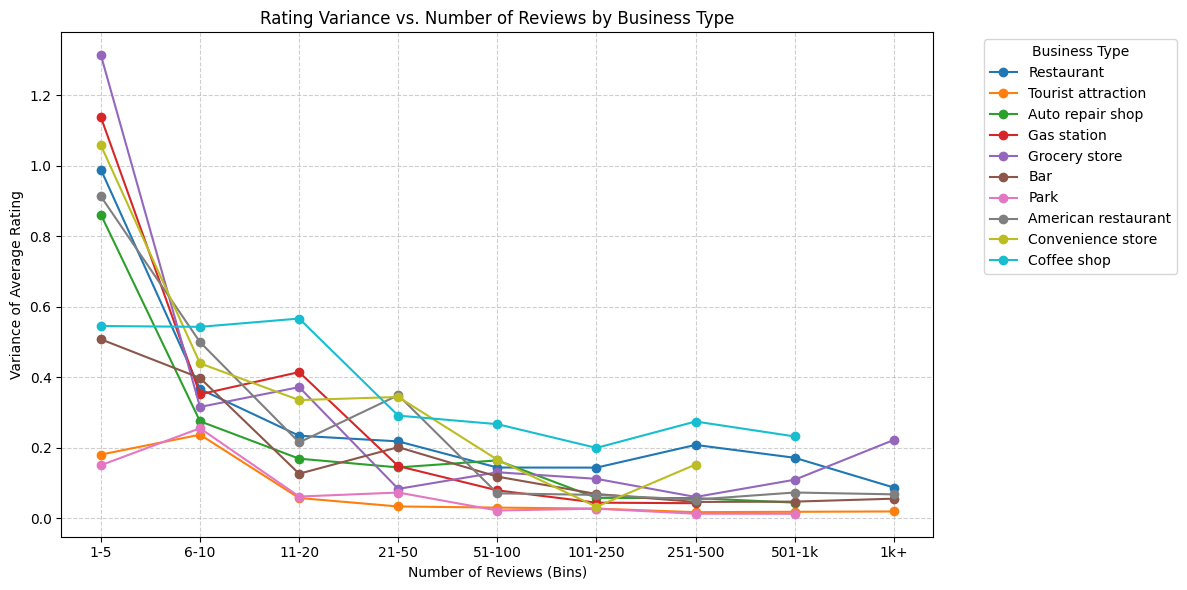

In [9]:
# Visualization: Plotting rating trends to identify stability thresholds
plt.figure(figsize=(12, 6))

for cat in top_cats:
    subset = stability_data[stability_data['category'] == cat]
    plt.plot(subset['review_bin'], subset['avg_rating'], marker='o', label=cat)

plt.title('Rating Variance vs. Number of Reviews by Business Type')
plt.xlabel('Number of Reviews (Bins)')
plt.ylabel('Variance of Average Rating')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
# --- EXPORT VOLATILITY PLOT DATA FOR TABLEAU ---

# Add the state column before exporting
stability_data['state'] = STATE_NAME

# Save with the state name in the filename
stability_data.to_csv(f'{STATE_NAME}_category_volatility_plot.csv', index=False)

print(f"Exported volatility data for {STATE_NAME}")

Exported volatility data for Vermont
